<a href="https://colab.research.google.com/github/ElianaHeitner/CNN-and-MLP-project/blob/main/Task_5_creative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 5- creative part


In [4]:
# 1. Imports and Data Loading
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
print("Data loaded successfully!")

Data loaded successfully!


In [5]:
# 2. Creative Architecture: Receptive Field Fusion (Patch-based MLP + CNN)
class ReceptiveFieldFusionNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Branch 1: Global CNN
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # CNN output: 64 channels * 8 * 8 = 4096 features

        # Branch 2: Local Patch-MLP (Shared weights for all 4 quadrants)
        # Each quadrant of a 32x32 image is 16x16. With 3 color channels = 3 * 16 * 16 = 768
        self.patch_mlp = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        # 4 quadrants * 64 features = 256 patch features

        # Final Fusion Classifier (4096 from CNN + 256 from Patches = 4352 total features)
        self.classifier = nn.Sequential(
            nn.Linear(4352, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        # 1. Process Global CNN
        cnn_out = self.cnn_branch(x)
        cnn_out = cnn_out.view(cnn_out.size(0), -1) # Flatten

        # 2. Extract Patches (Top-Left, Top-Right, Bottom-Left, Bottom-Right)
        tl = x[:, :, :16, :16].contiguous().view(x.size(0), -1)
        tr = x[:, :, :16, 16:].contiguous().view(x.size(0), -1)
        bl = x[:, :, 16:, :16].contiguous().view(x.size(0), -1)
        br = x[:, :, 16:, 16:].contiguous().view(x.size(0), -1)

        # Process each patch through the shared MLP
        patch_tl = self.patch_mlp(tl)
        patch_tr = self.patch_mlp(tr)
        patch_bl = self.patch_mlp(bl)
        patch_br = self.patch_mlp(br)

        # Concatenate all local patch features
        patches_out = torch.cat((patch_tl, patch_tr, patch_bl, patch_br), dim=1)

        # 3. Fuse Global and Local features
        fused_features = torch.cat((cnn_out, patches_out), dim=1)

        # 4. Final Classification
        return self.classifier(fused_features)

hybrid_model = ReceptiveFieldFusionNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(hybrid_model.parameters(), lr=0.001)

total_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f"Receptive Field Fusion Net Total Parameters: {total_params:,}")

Receptive Field Fusion Net Total Parameters: 2,359,946


In [6]:
# 3. Training and Evaluation Loop
def train(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

def test(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

num_epochs = 15
print("Starting training of the Fusion Model...")
for epoch in range(num_epochs):
    train_loss, train_acc = train(hybrid_model, train_loader)
    test_loss, test_acc = test(hybrid_model, test_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Starting training of the Fusion Model...
Epoch 1/15 | Train Acc: 49.43% | Test Acc: 59.30%
Epoch 2/15 | Train Acc: 63.99% | Test Acc: 67.94%
Epoch 3/15 | Train Acc: 70.28% | Test Acc: 70.24%
Epoch 4/15 | Train Acc: 74.46% | Test Acc: 71.45%
Epoch 5/15 | Train Acc: 78.00% | Test Acc: 73.18%
Epoch 6/15 | Train Acc: 81.56% | Test Acc: 73.83%
Epoch 7/15 | Train Acc: 84.43% | Test Acc: 74.52%
Epoch 8/15 | Train Acc: 87.30% | Test Acc: 74.69%
Epoch 9/15 | Train Acc: 89.39% | Test Acc: 73.85%
Epoch 10/15 | Train Acc: 91.34% | Test Acc: 74.73%
Epoch 11/15 | Train Acc: 92.79% | Test Acc: 74.69%
Epoch 12/15 | Train Acc: 93.92% | Test Acc: 74.33%
Epoch 13/15 | Train Acc: 94.70% | Test Acc: 73.87%
Epoch 14/15 | Train Acc: 95.38% | Test Acc: 73.25%
Epoch 15/15 | Train Acc: 95.78% | Test Acc: 74.03%


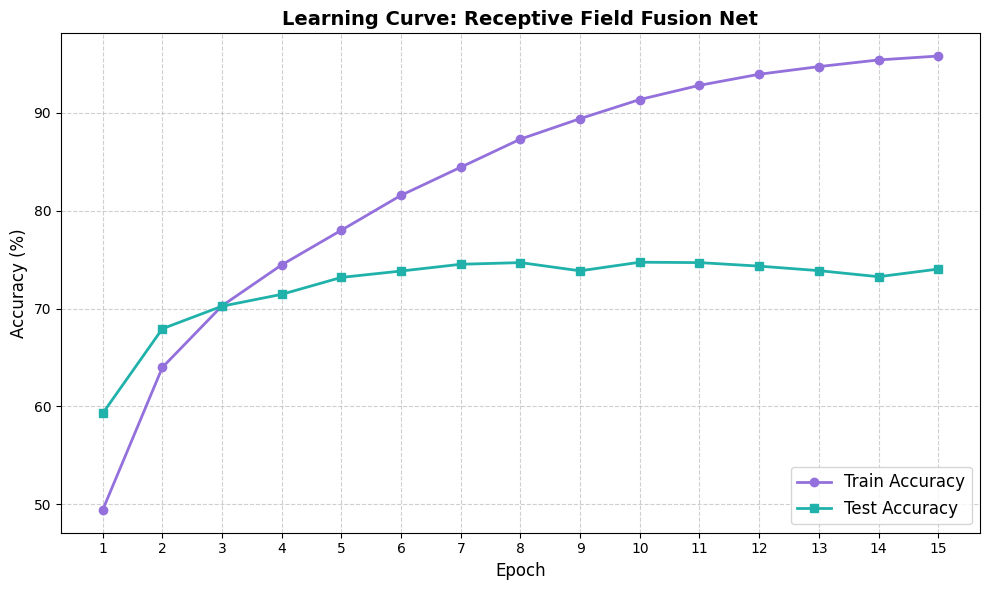

In [7]:
# 4. Extra Analysis: Learning Curve Visualization
import matplotlib.pyplot as plt

# Using the exact accuracy results from your training run
epochs = list(range(1, 16))
train_acc = [49.43, 63.99, 70.28, 74.46, 78.00, 81.56, 84.43, 87.30, 89.39, 91.34, 92.79, 93.92, 94.70, 95.38, 95.78]
test_acc = [59.30, 67.94, 70.24, 71.45, 73.18, 73.83, 74.52, 74.69, 73.85, 74.73, 74.69, 74.33, 73.87, 73.25, 74.03]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy', color='mediumpurple', linewidth=2, markersize=6)
plt.plot(epochs, test_acc, marker='s', label='Test Accuracy', color='lightseagreen', linewidth=2, markersize=6)

plt.title('Learning Curve: Receptive Field Fusion Net', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()

# Display the beautiful output!
plt.show()